# Select experts, then train ReliFuse

Use this path when you have more candidate models than you want to fuse. `SelectionConfig.max_experts` is the requested selected `K`, and it must not exceed the number of loaded candidate models.


In [1]:
import sys
import tempfile
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

import torch

from examples.loaded_expert_demo import (
    create_demo_checkpoints,
    load_expert_models,
    make_synthetic_vessel_split,
    plot_fusion_case,
    predict_stack,
)
from relifuse import ReliFuse, TrainingConfig, expert_dice_scores, fit, seed_everything

seed_everything(7)

from relifuse import SelectionConfig, select_from_validation, subset_expert_predictions


In [2]:
# Demo data: license-clean synthetic vessel masks.
# Replace this cell with your real Dataset/DataLoader. Keep outputs as [B,1,H,W].
train_images, train_masks = make_synthetic_vessel_split(10, seed=10)
validation_images, validation_masks = make_synthetic_vessel_split(5, seed=20)
test_images, test_masks = make_synthetic_vessel_split(3, seed=30)

print(train_images.shape, validation_images.shape, test_images.shape)


torch.Size([10, 1, 48, 48]) torch.Size([5, 1, 48, 48]) torch.Size([3, 1, 48, 48])


In [3]:
# Demo only: candidate expert checkpoints live in tempdir.
# In real use, put your own checkpoint metadata in expert_specs/checkpoint_paths.
tmp = tempfile.TemporaryDirectory()
expert_specs = [
    ("tiny_cnn_a", "cnn", 6, 1),
    ("tiny_cnn_b", "cnn", 8, 2),
    ("tiny_context_a", "context", 10, 1),
    ("tiny_context_b", "context", 12, 2),
    ("tiny_wide", "wide", 14, 1),
]
checkpoints = create_demo_checkpoints(tmp.name, train_images, train_masks, expert_specs)
models = load_expert_models(checkpoints)
names = [checkpoint.name for checkpoint in checkpoints]
families = [checkpoint.family for checkpoint in checkpoints]

candidate_train = predict_stack(models, train_images)
candidate_validation = predict_stack(models, validation_images)
candidate_test = predict_stack(models, test_images)
print(candidate_train.shape)


torch.Size([10, 5, 48, 48])


In [4]:
requested_k = 3
if requested_k > len(models):
    raise ValueError("requested_k cannot exceed the number of candidate models")

selection = select_from_validation(
    candidate_validation,
    validation_masks,
    families=families,
    names=names,
    config=SelectionConfig(max_experts=requested_k, family_cap=2, recall_floor=0.0, minimum_gain=0.0),
)
print("selected:", selection.selected_names)
print("indices:", selection.selected_indices)
print("validation dice:", selection.quality.tolist())


selected: ('tiny_cnn_a', 'tiny_wide', 'tiny_cnn_b')
indices: (0, 4, 1)
validation dice: [0.9527524709701538, 0.7850329875946045, 0.9311224222183228, 0.9068425297737122, 0.9423728585243225]


In [5]:
train_predictions = subset_expert_predictions(candidate_train, selection.selected_indices)
validation_predictions = subset_expert_predictions(candidate_validation, selection.selected_indices)
test_predictions = subset_expert_predictions(candidate_test, selection.selected_indices)
selected_quality = selection.quality[list(selection.selected_indices)]

fusion = ReliFuse(num_experts=len(selection.selected_indices), expert_scores=selected_quality)
history = fit(
    fusion,
    train_predictions,
    train_masks,
    validation_predictions,
    validation_masks,
    config=TrainingConfig(epochs=3, batch_size=2, patience=3),
)
print(history.to_dict())


{'records': [{'epoch': 1, 'train_loss': 0.1327434480190277, 'train_dice': 0.9398837685585022, 'validation_loss': 0.1225594977537791, 'validation_dice': 0.9511200388272604, 'learning_rate': 0.001}, {'epoch': 2, 'train_loss': 0.11690987199544907, 'train_dice': 0.9458076119422912, 'validation_loss': 0.10584864765405655, 'validation_dice': 0.9555362264315287, 'learning_rate': 0.0007625}, {'epoch': 3, 'train_loss': 0.10415932685136794, 'train_dice': 0.9488577604293823, 'validation_loss': 0.09936279555161794, 'validation_dice': 0.9547895987828573, 'learning_rate': 0.0002875000000000001}], 'best_epoch': 3, 'best_validation_loss': 0.09936279555161794, 'best_validation_dice': 0.9547895987828573}


torch.Size([3, 1, 48, 48]) torch.Size([3, 1, 48, 48])


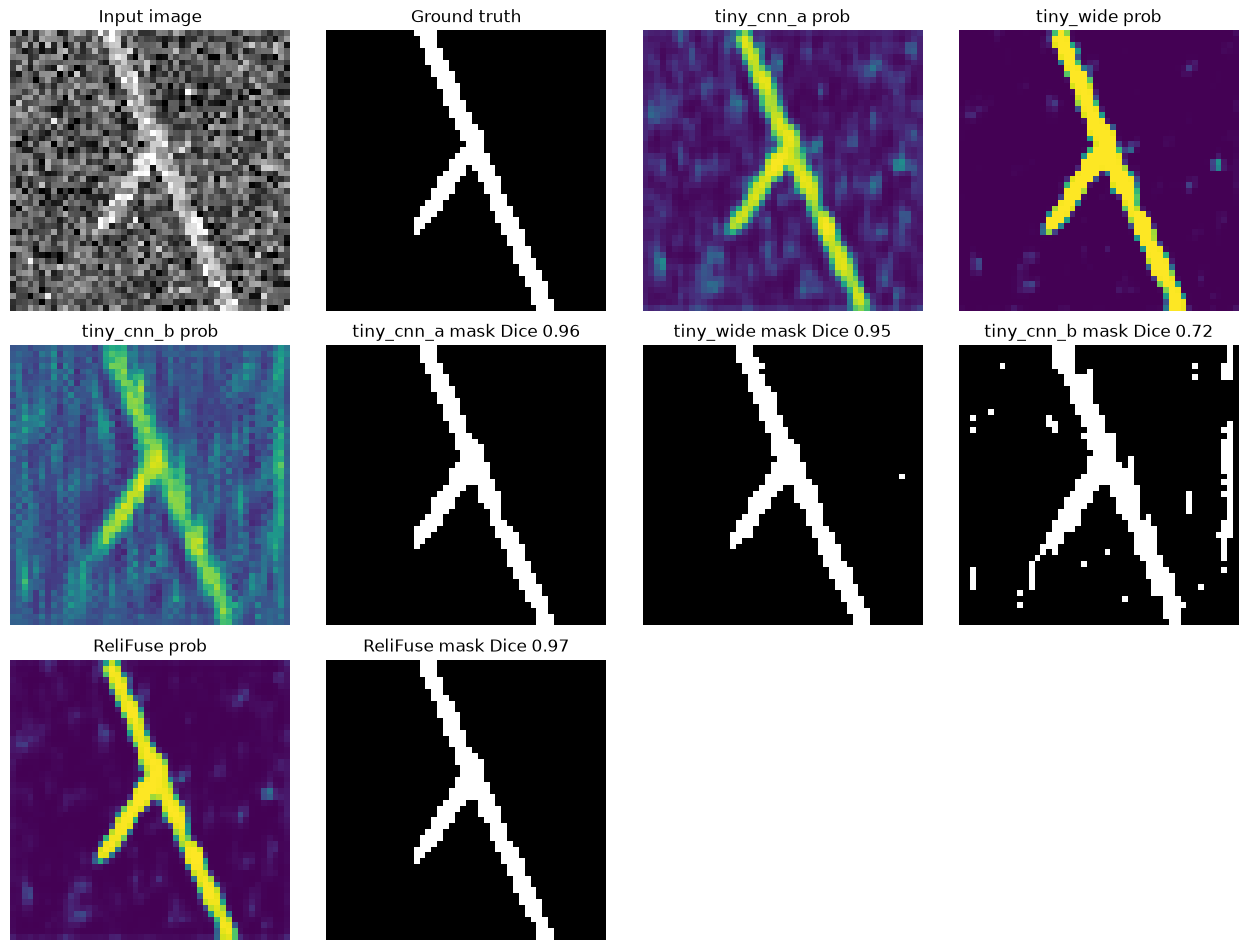

In [6]:
with torch.inference_mode():
    fused_probability = fusion.fuse(test_predictions)
    fused_mask = fusion.fuse(test_predictions, threshold=0.5)

print(fused_probability.shape, fused_mask.shape)
plot_fusion_case(
    test_images[0],
    test_masks[0],
    test_predictions[0],
    fused_probability[0],
    expert_names=selection.selected_names,
)
tmp.cleanup()
